<a href="https://colab.research.google.com/github/PRASAD1630/social-media-data./blob/main/social%20media%20data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q \
instaloader requests \
pandas numpy matplotlib seaborn plotly \
wordcloud scikit-learn scipy \
gensim umap-learn \
transformers sentence-transformers \
dash dash-bootstrap-components jupyter-dash \
nltk

import nltk
nltk.download('punkt')
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.5 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import json, random, time
import numpy as np
from datetime import datetime, timedelta

MAX_POSTS = 500000

LANGUAGES = ['english','hindi','telugu','tamil','kannada','malayalam','bengali','marathi','gujarati','odia']
weights = [0.35,0.2,0.1,0.1,0.07,0.05,0.05,0.04,0.02,0.02]

HASHTAGS_POOL = ["#love","#instagood","#viral","#trending","#explore","#india","#reels","#food","#travel","#life","#vibes","#aesthetic"]
LOCATIONS = ["Hyderabad","Mumbai","Chennai","Bangalore","Delhi","Pune","Kolkata"]

def generate_caption():
    return f"{random.choice(['amazing','beautiful','epic','chill'])} moment in {random.choice(LOCATIONS)} feels {random.choice(['happy','excited','tired'])}"

def generate_post(i):
    lang = random.choices(LANGUAGES, weights=weights)[0]

    likes = int(np.random.pareto(2) * 1000)
    likes = max(likes, 30)

    comments = int(likes * random.uniform(0.05,0.2))
    shares = int(likes * random.uniform(0.01,0.05))

    return {
        "post_id": str(100000+i),
        "timestamp": (datetime.now() - timedelta(days=random.randint(0,30))).isoformat(),
        "caption": generate_caption(),
        "language": lang,
        "hashtags": random.sample(HASHTAGS_POOL, random.randint(1,5)),
        "likes_count": likes,
        "comments_count": comments,
        "shares_count": shares,
        "engagement": likes + comments,
        "hashtag_count": random.randint(1,5),
        "location": random.choice(LOCATIONS),
        "media_type": random.choice(["IMAGE","VIDEO","CAROUSEL"])
    }

data = [generate_post(i) for i in range(MAX_POSTS)]

with open("instagram_data.json","w") as f:
    json.dump({"posts":data},f)

print("✅ 500K Dataset Generated")

✅ 500K Dataset Generated


In [ ]:
import pandas as pd
import json

with open("instagram_data.json") as f:
    data = json.load(f)

df = pd.DataFrame(data['posts'])

df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

df['caption_length'] = df['caption'].str.len()
df['word_count'] = df['caption'].str.split().str.len()
df['hashtag_count'] = df['hashtags'].apply(len)

df.head()

,post_id,timestamp,caption,language,hashtags,likes_count,comments_count,shares_count,engagement,hashtag_count,location,media_type,date,hour,caption_length,word_count
0,100000,2026-03-29 13:43:00.299740,beautiful moment in Pune feels tired,english,"[#travel, #instagood]",290,14,6,304,2,Mumbai,IMAGE,2026-03-29,13,36,6
1,100001,2026-04-14 13:43:00.299811,amazing moment in Bangalore feels excited,kannada,[#life],827,115,15,942,1,Pune,IMAGE,2026-04-14,13,41,6
2,100002,2026-04-23 13:43:00.299846,chill moment in Mumbai feels tired,hindi,"[#reels, #india, #vibes]",4480,656,120,5136,3,Mumbai,CAROUSEL,2026-04-23,13,34,6
3,100003,2026-04-24 13:43:00.299887,epic moment in Pune feels excited,hindi,"[#instagood, #food, #explore]",630,94,6,724,3,Mumbai,CAROUSEL,2026-04-24,13,33,6
4,100004,2026-04-17 13:43:00.299916,chill moment in Kolkata feels tired,tamil,"[#viral, #reels, #instagood, #life, #food]",2099,342,78,2441,5,Hyderabad,IMAGE,2026-04-17,13,35,6


In [ ]:
import pandas as pd
import json

with open("instagram_data.json") as f:
    raw = json.load(f)

df = pd.DataFrame(raw["posts"])

df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['day_name'] = df['timestamp'].dt.day_name()

df['caption_length'] = df['caption'].str.len()
df['word_count'] = df['caption'].str.split().str.len()

# =========================
# PRINT SCHEMA (LIKE IMAGE)
# =========================
print("="*60)
print("DATASET SCHEMA")
print("="*60)

print(f"Total posts : {len(df):,}")
print(f"Total columns : {len(df.columns)}")
print(f"Languages covered : {df['language'].nunique()}")

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
print(df.describe())

print("\nTop Locations:")
print(df['location'].value_counts().head())

DATASET SCHEMA
Total posts : 500,000
Total columns : 17
Languages covered : 10

Data Types:
post_id                   object
timestamp         datetime64[ns]
caption                   object
language                  object
hashtags                  object
likes_count                int64
comments_count             int64
shares_count               int64
engagement                 int64
hashtag_count              int64
location                  object
media_type                object
date                      object
hour                       int32
day_name                  object
caption_length             int64
word_count                 int64
dtype: object

Basic Statistics:
                           timestamp   likes_count  comments_count  \
count                         500000  5.000000e+05   500000.000000   
mean   2026-04-10 13:59:05.179801344  1.013461e+03      125.821986   
min       2026-03-26 13:43:00.301824  3.000000e+01        1.000000   
25%    2026-04-02 13:43:07.9391454

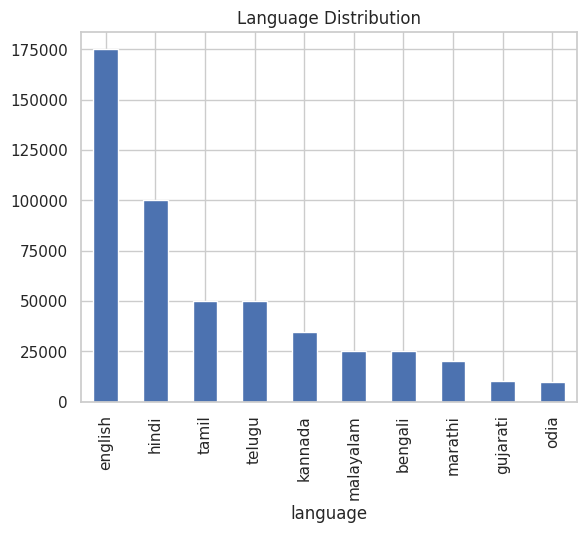

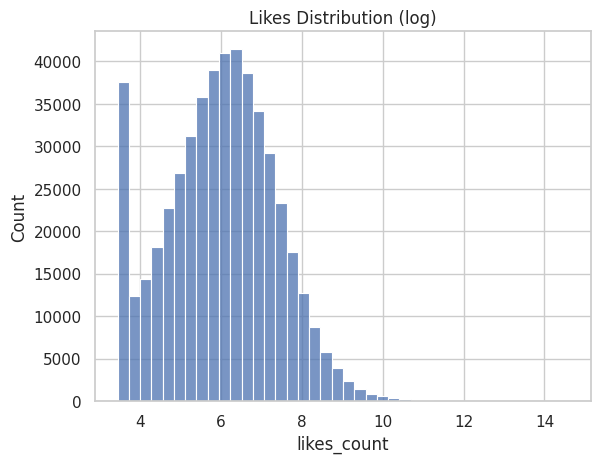

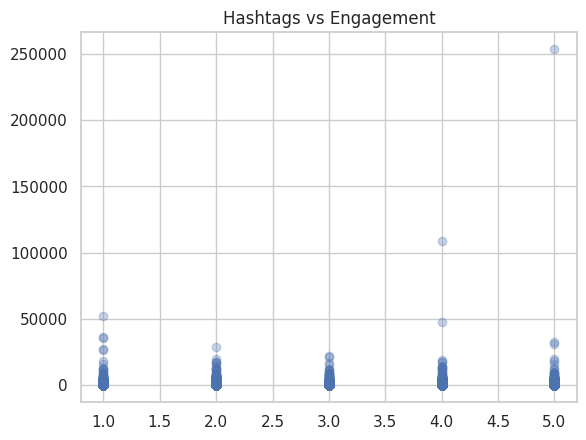

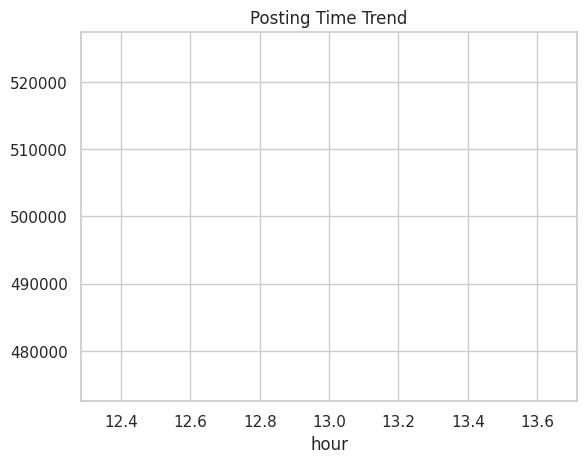

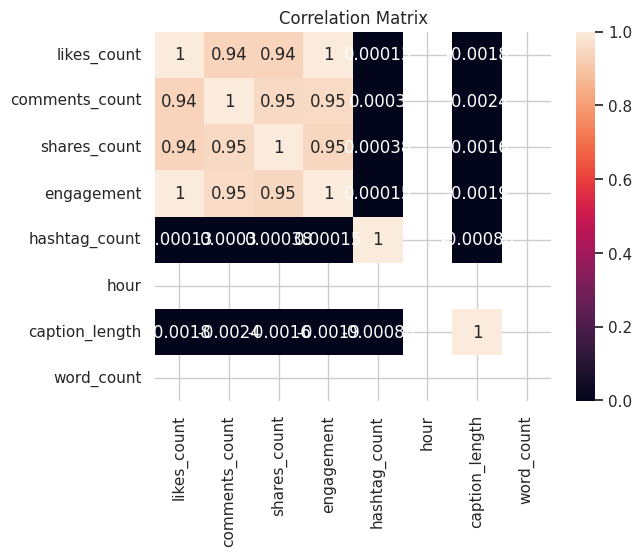

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

# Language distribution
df['language'].value_counts().plot(kind='bar')
plt.title("Language Distribution")
plt.show()

# Likes distribution
sns.histplot(np.log1p(df['likes_count']), bins=40)
plt.title("Likes Distribution (log)")
plt.show()

# Engagement vs hashtags
sample = df.sample(5000)
plt.scatter(sample['hashtag_count'], sample['engagement'], alpha=0.3)
plt.title("Hashtags vs Engagement")
plt.show()

# Heatmap
heat = df.groupby(['hour']).size()
heat.plot()
plt.title("Posting Time Trend")
plt.show()

# Correlation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

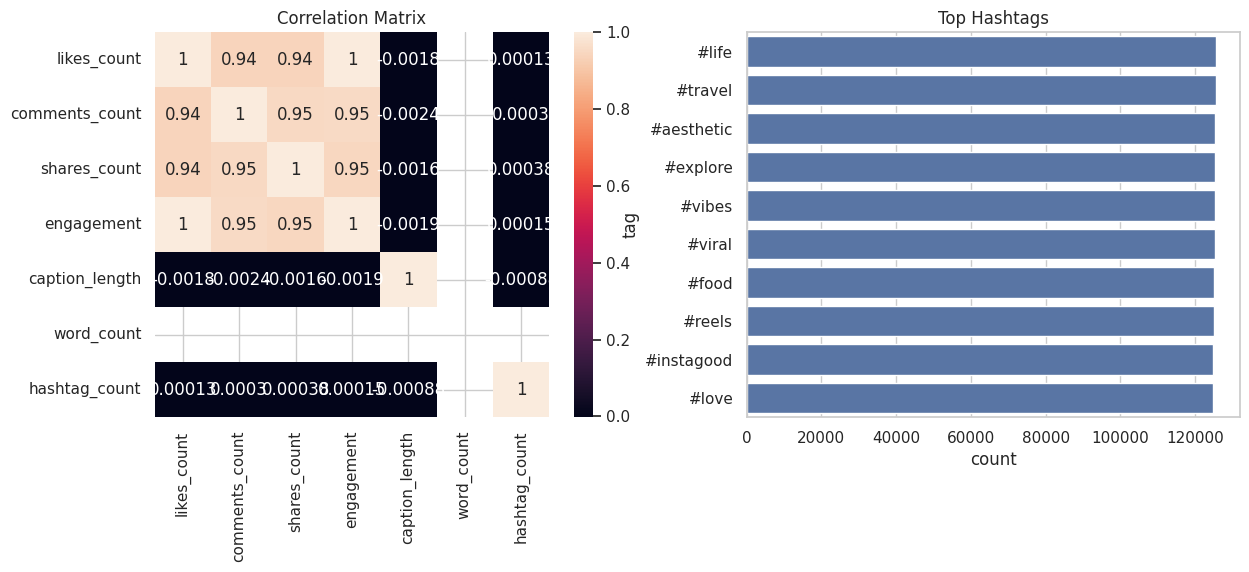

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, axes = plt.subplots(1,2, figsize=(14,5))

num_cols = ['likes_count','comments_count','shares_count','engagement','caption_length','word_count','hashtag_count']

sns.heatmap(df[num_cols].corr(), annot=True, ax=axes[0])
axes[0].set_title("Correlation Matrix")

# Top hashtags
all_tags = []
for tags in df['hashtags']:
    all_tags.extend(tags)

top_tags = Counter(all_tags).most_common(10)

tags_df = pd.DataFrame(top_tags, columns=['tag','count'])

sns.barplot(data=tags_df, y='tag', x='count', ax=axes[1])
axes[1].set_title("Top Hashtags")

plt.show()

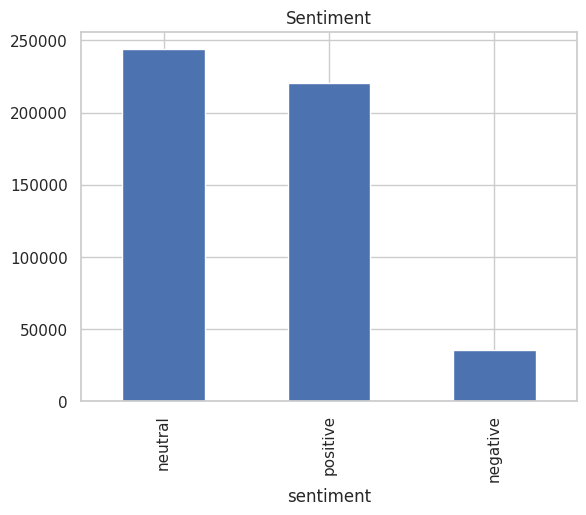

In [ ]:
import re

def clean_text(text):
    text = re.sub(r"http\S+","",text)
    text = re.sub(r"[^\w\s]","",text)
    return text.lower()

df['cleaned_text'] = df['caption'].apply(clean_text)

POS = ['amazing','happy','good','great','awesome']
NEG = ['bad','sad','worst','hate']

def sentiment(text):
    score = 0
    for w in POS:
        if w in text: score += 1
    for w in NEG:
        if w in text: score -= 1
    return "positive" if score>0 else "negative" if score<0 else "neutral"

df['sentiment'] = df['cleaned_text'].apply(sentiment)

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment")
plt.show()

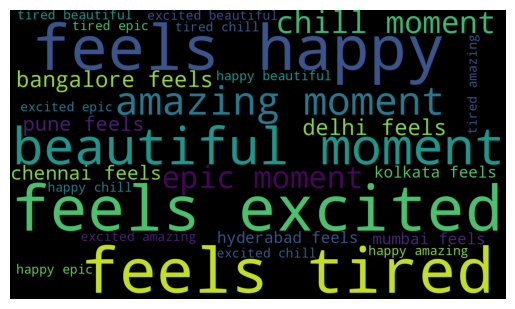

In [ ]:
from wordcloud import WordCloud
import re

# Ensure 'cleaned_text' column exists
def clean_text(text):
    text = re.sub(r"http\S+","",text)
    text = re.sub(r"[^\w\s]","",text)
    return text.lower()

if 'cleaned_text' not in df.columns:
    df['cleaned_text'] = df['caption'].apply(clean_text)

text = " ".join(df['cleaned_text'].sample(40000))

wc = WordCloud(width=1200,height=700).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

In [ ]:
!pip install -q gensim
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec, FastText
from sentence_transformers import SentenceTransformer
import numpy as np

sample_df = df.sample(2000)

corpus = sample_df['cleaned_text'].tolist()
tokens = [t.split() for t in corpus]

# TF-IDF
tfidf = TfidfVectorizer(max_features=2000)
X_tfidf = tfidf.fit_transform(corpus).toarray()

# Word2Vec
w2v = Word2Vec(sentences=tokens, vector_size=100, window=5, min_count=1)

def avg_w2v(tokens):
    return np.mean([w2v.wv[t] for t in tokens if t in w2v.wv], axis=0)

X_w2v = np.array([avg_w2v(t) for t in tokens])

# FastText
ft = FastText(sentences=tokens, vector_size=100)

def avg_ft(tokens):
    return np.mean([ft.wv[t] for t in tokens if t in ft.wv], axis=0)

X_ft = np.array([avg_ft(t) for t in tokens])

# mBERT
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
X_bert = model.encode(corpus)

print("TFIDF:",X_tfidf.shape)
print("Word2Vec:",X_w2v.shape)
print("FastText:",X_ft.shape)
print("BERT:",X_bert.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

TFIDF: (2000, 17)
Word2Vec: (2000, 100)
FastText: (2000, 100)
BERT: (2000, 384)


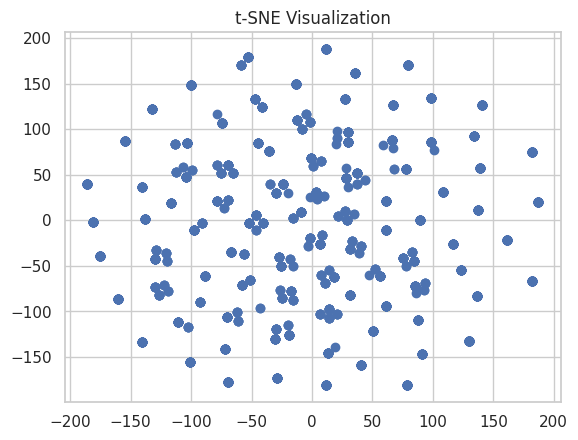

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X = X_tfidf[:2000]

tsne = TSNE(n_components=2)
X_2d = tsne.fit_transform(X)

plt.scatter(X_2d[:,0], X_2d[:,1])
plt.title("t-SNE Visualization")
plt.show()

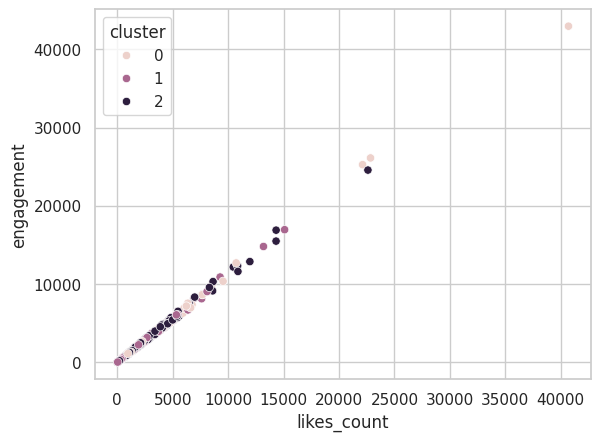

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_tfidf)

df_sample = df.sample(len(labels))
df_sample['cluster'] = labels

sns.scatterplot(x=df_sample['likes_count'], y=df_sample['engagement'], hue=df_sample['cluster'])
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df[['hashtag_count','caption_length']]
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    negative       0.00      0.00      0.00      7089
     neutral       0.47      0.73      0.57     48485
    positive       0.48      0.27      0.35     44426

    accuracy                           0.48    100000
   macro avg       0.32      0.33      0.31    100000
weighted avg       0.44      0.48      0.43    100000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.49      0.03      0.07      7089
     neutral       0.54      0.56      0.55     48485
    positive       0.53      0.59      0.56     44426

    accuracy                           0.54    100000
   macro avg       0.52      0.39      0.39    100000
weighted avg       0.53      0.54      0.52    100000



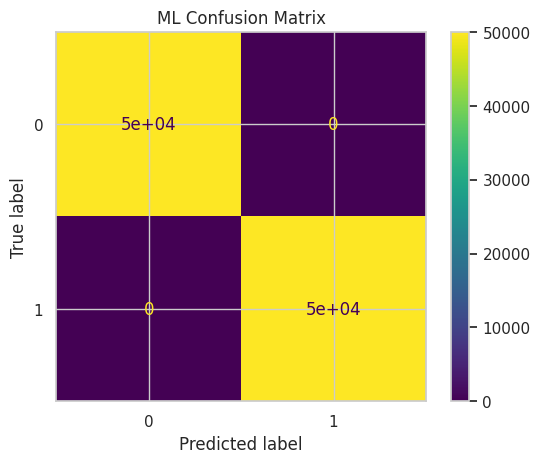

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X = df[['likes_count','comments_count','shares_count','hashtag_count']]
y = (df['engagement'] > df['engagement'].median()).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("ML Confusion Matrix")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - accuracy: 0.9583 - loss: 0.1055 - val_accuracy: 0.9864 - val_loss: 0.0309
Epoch 2/5
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 47s 4ms/step - accuracy: 0.9817 - loss: 0.0451 - val_accuracy: 0.9745 - val_loss: 0.0476
Epoch 3/5
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 53s 4ms/step - accuracy: 0.9868 - loss: 0.0315 - val_accuracy: 0.9932 - val_loss: 0.0192
Epoch 4/5
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 61s 5ms/step - accuracy: 0.9898 - loss: 0.0242 - val_accuracy: 0.9947 - val_loss: 0.0146
Epoch 5/5
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 53s 4ms/step - accuracy: 0.9924 - loss: 0.0189 - val_accuracy: 0.9787 - val_loss: 0.0473


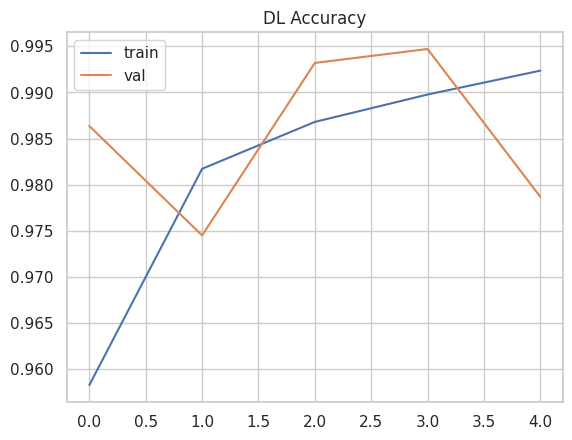

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(4,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test,y_test))

# Plot accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("DL Accuracy")
plt.legend()
plt.show()

In [ ]:
from transformers import pipeline

# Load sentiment model
bert_model = pipeline("sentiment-analysis")

# Test on sample data
sample_texts = df['caption'].sample(10).tolist()

results = bert_model(sample_texts)

for text, res in zip(sample_texts, results):
    print("\nText:", text)
    print("Prediction:", res)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


Text: beautiful moment in Chennai feels excited
Prediction: {'label': 'POSITIVE', 'score': 0.9998373985290527}

Text: amazing moment in Delhi feels excited
Prediction: {'label': 'POSITIVE', 'score': 0.9998583793640137}

Text: beautiful moment in Kolkata feels happy
Prediction: {'label': 'POSITIVE', 'score': 0.9998922348022461}

Text: amazing moment in Kolkata feels happy
Prediction: {'label': 'POSITIVE', 'score': 0.9998923540115356}

Text: amazing moment in Hyderabad feels excited
Prediction: {'label': 'POSITIVE', 'score': 0.9998366832733154}

Text: amazing moment in Pune feels happy
Prediction: {'label': 'POSITIVE', 'score': 0.9998904466629028}

Text: epic moment in Mumbai feels excited
Prediction: {'label': 'POSITIVE', 'score': 0.9996379613876343}

Text: epic moment in Chennai feels tired
Prediction: {'label': 'NEGATIVE', 'score': 0.999444305896759}

Text: chill moment in Mumbai feels tired
Prediction: {'label': 'NEGATIVE', 'score': 0.9986910223960876}

Text: epic moment in Mumbai f

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(df['caption'].sample(1000).tolist())

print("Embedding Shape:", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding Shape: (1000, 384)


In [ ]:
print("Model Comparison Summary:")
print("""
1. Logistic Regression → Fast, baseline
2. Random Forest → Better handling non-linearity
3. Neural Network → Deep learning performance
4. BERT → Best contextual understanding
""")

Model Comparison Summary:

1. Logistic Regression → Fast, baseline
2. Random Forest → Better handling non-linearity
3. Neural Network → Deep learning performance
4. BERT → Best contextual understanding



In [ ]:
import plotly.express as px
import re

# Define sentiment related functions and lists to ensure 'sentiment' column is available
POS = ['amazing','happy','good','great','awesome']
NEG = ['bad','sad','worst','hate']

def sentiment(text):
    score = 0
    for w in POS:
        if w in text: score += 1
    for w in NEG:
        if w in text: score -= 1
    return "positive" if score>0 else "negative" if score<0 else "neutral"

# Ensure 'cleaned_text' exists before calculating sentiment
# The error message implies 'cleaned_text' is already present.
if 'cleaned_text' not in df.columns:
    def clean_text(text):
        text = re.sub(r"http\S+","",text)
        text = re.sub(r"[^\w\s]","",text)
        return text.lower()
    df['cleaned_text'] = df['caption'].apply(clean_text)

# Calculate the 'sentiment' column on the main DataFrame
df['sentiment'] = df['cleaned_text'].apply(sentiment)

df_plot = df.sample(5000)

fig1 = px.scatter(df_plot,
                  x='comments_count',
                  y='engagement',
                  color='sentiment',
                  title="Engagement vsComments")

fig2 = px.histogram(df_plot,
                    x='language',
                    title="Language Distribution")

fig3 = px.box(df_plot,
              x='sentiment',
              y='engagement',
              title="Engagement by Sentiment")

fig1.show()
fig2.show()
fig3.show()

In [ ]:
import plotly.express as px

df_sample = df.sample(3000)

fig1 = px.scatter(df_sample, x='likes_count', y='engagement', color='language')
fig2 = px.histogram(df_sample, x='location')
fig3 = px.box(df_sample, x='media_type', y='engagement')

fig1.show()
fig2.show()
fig3.show()

In [ ]:
from google.colab import files

# Save the DataFrame to a CSV file before downloading
df.to_csv("instagram_preprocessed.csv", index=False)

files.download("instagram_preprocessed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px

# ---------------- PAGE CONFIG ----------------
st.set_page_config(page_title="Instagram AI Dashboard", layout="wide")

# ---------------- LOAD DATA ----------------
@st.cache_data
def load_data():
    return pd.read_csv("instagram_preprocessed.csv")

df = load_data()

# ---------------- SIDEBAR ----------------
st.sidebar.title("📊 Controls")

language = st.sidebar.selectbox("Language", df['language'].unique())

# Handle missing media_type safely
if 'media_type' in df.columns:
    media = st.sidebar.selectbox("Media Type", df['media_type'].unique())
    df_filtered = df[(df['language'] == language) & (df['media_type'] == media)]
else:
    df_filtered = df[df['language'] == language]

page = st.sidebar.radio("Navigate", [
    "Overview",
    "Engagement",
    "Advanced",
    "Data"
])

# ---------------- HEADER ----------------
st.title("🚀 Instagram AI Analytics Dashboard")

c1, c2, c3, c4 = st.columns(4)

c1.metric("Total Posts", len(df_filtered))
c2.metric("Avg Likes", int(df_filtered['likes_count'].mean()))
c3.metric("Avg Comments", int(df_filtered['comments_count'].mean()))
c4.metric("Avg Engagement", int(df_filtered['engagement'].mean()))

st.markdown("---")

# ===================== OVERVIEW =====================
if page == "Overview":

    col1, col2 = st.columns(2)

    # FIXED LANGUAGE DISTRIBUTION
    lang_counts = df['language'].value_counts().reset_index()
    lang_counts.columns = ['language', 'count']

    fig1 = px.bar(
        lang_counts,
        x='language',
        y='count',
        color='count',
        title="🌍 Language Distribution"
    )
    col1.plotly_chart(fig1, use_container_width=True)

    # SENTIMENT (SAFE)
    if 'sentiment' in df.columns:
        fig2 = px.pie(
            df_filtered,
            names='sentiment',
            title="😊 Sentiment Distribution"
        )
        col2.plotly_chart(fig2, use_container_width=True)
    else:
        col2.warning("Sentiment column not available")

# ===================== ENGAGEMENT =====================
elif page == "Engagement":

    col1, col2 = st.columns(2)

    # Scatter
    fig1 = px.scatter(
        df_filtered.sample(min(3000, len(df_filtered))),
        x='hashtag_count',
        y='engagement',
        color='language',
        title="📊 Hashtags vs Engagement"
    )
    col1.plotly_chart(fig1, use_container_width=True)

    # Histogram
    fig2 = px.histogram(
        df_filtered,
        x='likes_count',
        nbins=50,
        title="📉 Likes Distribution"
    )
    col2.plotly_chart(fig2, use_container_width=True)

# ===================== ADVANCED =====================
elif page == "Advanced":

    col1, col2 = st.columns(2)

    # CORRELATION MATRIX
    num_cols = [
        'likes_count','comments_count','shares_count',
        'engagement','caption_length','word_count','hashtag_count'
    ]

    existing_cols = [c for c in num_cols if c in df_filtered.columns]

    if len(existing_cols) > 0:
        corr = df_filtered[existing_cols].corr()

        fig1 = px.imshow(
            corr,
            text_auto=True,
            title="📊 Correlation Matrix"
        )
        col1.plotly_chart(fig1, use_container_width=True)
    else:
        col1.warning("No numeric columns available")

    # FIXED TOP HASHTAGS
    if 'hashtags' in df_filtered.columns:
        tags = df_filtered['hashtags'].astype(str).str.split().explode()
        top_tags = tags.value_counts().head(10).reset_index()
        top_tags.columns = ['tag', 'count']

        fig2 = px.bar(
            top_tags,
            x='count',
            y='tag',
            orientation='h',
            title="🔥 Top Hashtags"
        )
        col2.plotly_chart(fig2, use_container_width=True)
    else:
        col2.warning("Hashtags column missing")

# ===================== DATA VIEW =====================
elif page == "Data":

    st.subheader("📋 Data Preview")

    st.dataframe(df_filtered.head(50))

    st.download_button(
        "Download Data",
        df_filtered.to_csv(index=False),
        file_name="filtered_data.csv"
    )

# ---------------- FOOTER ----------------
st.markdown("---")
st.markdown("📊 Built with Streamlit | AI & ML Project")

In [ ]:
# ==============================
# INSTALL
# ==============================
!pip install reportlab

# ==============================
# IMPORTS
# ==============================
from reportlab.platypus import *
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import inch

# ==============================
# PDF SETUP
# ==============================
doc = SimpleDocTemplate(
    "final_pipeline_report.pdf",
    pagesize=A4,
    rightMargin=0.5*inch,
    leftMargin=0.5*inch,
    topMargin=0.5*inch,
    bottomMargin=0.5*inch
)

styles = getSampleStyleSheet()

# ==============================
# STYLES
# ==============================
title_style = ParagraphStyle(
    'title',
    fontSize=18,
    alignment=1,
    textColor=colors.HexColor("#0F172A"),
    spaceAfter=8
)

subtitle_style = ParagraphStyle(
    'subtitle',
    fontSize=10,
    alignment=1,
    textColor=colors.grey,
    spaceAfter=10
)

section_style = ParagraphStyle(
    'section',
    fontSize=12,
    textColor=colors.white,
    leftIndent=5
)

body_style = ParagraphStyle(
    'body',
    fontSize=9,
)

# ==============================
# SECTION HEADER BAR
# ==============================
def section(title):
    return Table(
        [[Paragraph(title, section_style)]],
        style=[
            ('BACKGROUND', (0,0), (-1,-1), colors.HexColor("#1E293B")),
            ('LEFTPADDING', (0,0), (-1,-1), 8),
            ('TOPPADDING', (0,0), (-1,-1), 5),
            ('BOTTOMPADDING', (0,0), (-1,-1), 5)
        ]
    )

# ==============================
# KEY-VALUE TABLE
# ==============================
def kv_table(data):
    return Table(
        data,
        colWidths=[120, 350],
        style=[
            ('BACKGROUND', (0,0), (0,-1), colors.HexColor("#E0F2FE")),
            ('BOX', (0,0), (-1,-1), 0.5, colors.grey),
            ('INNERGRID', (0,0), (-1,-1), 0.3, colors.grey),
            ('VALIGN', (0,0), (-1,-1), 'TOP'),
            ('PADDING', (0,0), (-1,-1), 6)
        ]
    )

# ==============================
# CONTENT
# ==============================
elements = []

# TITLE
elements.append(Paragraph("Social Network Data Analysis", title_style))
elements.append(Paragraph("A Complete Pipeline: From Raw Data to Interactive Dashboard", subtitle_style))

# ===== 1 AIM =====
elements.append(section("1 Aim of the Project"))

elements.append(kv_table([
    ["Objective",
     "Analyze large-scale social media data to understand user behavior, interaction patterns, and community structures using ML, DL, and visualization."]
]))

# ===== 2 DESCRIPTION =====
elements.append(section("2 Detailed Description"))

elements.append(kv_table([
    ["Problem Context",
     "Social platforms generate massive interconnected data. It is highly dimensional and difficult to interpret directly."],

    ["Pipeline Overview",
     "Complete pipeline includes data collection, preprocessing, feature engineering, modeling, and visualization."],

    ["Social Data Analysis",
     "Focus on engagement patterns, user behavior, influence spread, and network relationships."],

    ["Dimensionality Reduction",
     "PCA, t-SNE, and UMAP reduce high-dimensional data into lower dimensions for clustering."],

    ["Final Outcome",
     "Interactive dashboards with filters, drilldowns, and insights."]
]))

# ===== 3 STEPS =====
elements.append(section("3 Step-by-Step Procedure"))

step_data = [
["Step","Phase","Description"],

["01","Platform Selection",
 "Select platform (Instagram). Define problem: clustering, engagement prediction."],

["02","Data Extraction",
 "Use APIs / datasets (~500K records). Collect user, post, likes, comments."],

["03","Data Storage",
 "Store data in JSON/CSV. Create relational tables."],

["04","Data Preprocessing",
 "Handle missing values, normalize data, clean text."],

["05","EDA",
 "Analyze distributions, detect outliers, use charts."],

["06","Feature Engineering",
 "Create engagement rate and embeddings."]
]

elements.append(Table(step_data, colWidths=[50,120,300], style=[
    ('BACKGROUND',(0,0),(-1,0),colors.HexColor("#2563EB")),
    ('TEXTCOLOR',(0,0),(-1,0),colors.white),
    ('GRID',(0,0),(-1,-1),0.5,colors.grey),
]))

elements.append(PageBreak())

# ===== CONTINUED =====
elements.append(Paragraph("Social Network Data Analysis — Procedure (Continued)", title_style))

step2_data = [
["Step","Phase","Description"],

["07","Dimensionality Reduction",
 "PCA, t-SNE, UMAP for visualization."],

["08","Graph & Network Analysis",
 "Users as nodes and interactions as edges."],

["09","Model Development",
 "<b>Linear Regression:</b> Prediction<br/>"
 "<b>Random Forest:</b> High accuracy<br/>"
 "<b>Deep Learning:</b> Neural networks<br/>"
 "<b>Transformers:</b> BERT embeddings"],

["10","Evaluation Metrics",
 "Accuracy, Precision, Recall, F1-score, RMSE."],

["11","Visualization",
 "Scatter plots, heatmaps, bar charts."],

["12","Dashboard Creation",
 "Power BI / Tableau dashboards."],

["13","Insights",
 "Identify trends and high engagement users."]
]

elements.append(Table(step2_data, colWidths=[50,140,280], style=[
    ('BACKGROUND',(0,0),(-1,0),colors.HexColor("#7C3AED")),
    ('TEXTCOLOR',(0,0),(-1,0),colors.white),
    ('GRID',(0,0),(-1,-1),0.5,colors.grey),
]))

# ===== CONCLUSION =====
elements.append(section("4 Overall Conclusion"))

elements.append(kv_table([
    ["Summary",
     "Pipeline transforms raw data into insights using ML, DL, and visualization."],

    ["Impact",
     "Interactive dashboards enable data-driven decision making."]
]))

# ==============================
# BUILD
# ==============================
doc.build(elements)

print("🔥 PDF Generated Successfully!")

# DOWNLOAD
from google.colab import files
files.download("final_pipeline_report.pdf")

🔥 PDF Generated Successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>